In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. Rutas de los archivos
csv_path = r'D:\R\RFSI paper\completed_daily_dataset.csv'
shp_path = r'D:\R\RFSI paper\BlockVC\Shp\watershed.shp'

# 2. Cargar el archivo SHP de la cuenca
cuenca = gpd.read_file(shp_path)

# 3. Cargar el CSV con los datos diarios
# Asumimos que el CSV usa comas como separador
df = pd.read_csv(csv_path)

# 4. Convertir el DataFrame de estaciones en un GeoDataFrame
# Usamos las columnas 'x' e 'y' que se ven en tu imagen
geometry = [Point(xy) for xy in zip(df['x'], df['y'])]
gdf_estaciones = gpd.GeoDataFrame(df, geometry=geometry)

# 5. Asegurar que ambos archivos tengan el mismo sistema de coordenadas (CRS)
# Generalmente PISCO/SENAMHI usan WGS84 (EPSG:4326)
if gdf_estaciones.crs is None:
    gdf_estaciones.set_crs(epsg=4326, inplace=True)

if cuenca.crs != gdf_estaciones.crs:
    cuenca = cuenca.to_crs(gdf_estaciones.crs)

# 6. Realizar el recorte espacial (Spatial Join)
# Esto selecciona solo las estaciones que están "dentro" del polígono de la cuenca
estaciones_cuenca = gpd.sjoin(gdf_estaciones, cuenca, predicate='within')

# 7. Limpiar y guardar el resultado
# Eliminamos la columna geometry y las columnas extras del join si prefieres un CSV limpio
df_final = pd.DataFrame(estaciones_cuenca.drop(columns=['geometry', 'index_right']))

output_path = r'D:\R\RFSI paper\estaciones_huallaga2.csv'
df_final.to_csv(output_path, index=False)

print(f"Proceso terminado. Se extrajeron {len(df_final)} estaciones para la cuenca.")
print(f"Archivo guardado en: {output_path}")

Proceso terminado. Se extrajeron 0 estaciones para la cuenca.
Archivo guardado en: D:\R\RFSI paper\estaciones_huallaga2.csv


In [1]:
import pandas as pd
import geopandas as gpd
import rasterio # Necesitas instalarlo: pip install rasterio
from shapely.geometry import Point

# 1. Cargar tus estaciones filtradas de la cuenca
csv_path = r'D:\R\RFSI paper\estaciones_huallaga.csv'
df = pd.read_csv(csv_path)

# Convertir a GeoDataFrame (asumiendo que x e y en el CSV son WGS84)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs="EPSG:4326")

# 2. Lista de tus archivos raster estáticos (¡Agregado el SD de 5km!)
static_files = {
    'elevation': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/dem_utm.tif', 
    'slope': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/slope_utm.tif',
    'aspect_cos': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/cos_utm.tif',
    'aspect_sin': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/sin_utm.tif',
    'twi': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/twi_utm.tif',
    # NUEVO: Ruta al raster de desviación estándar de 5km que creaste en R
    'sd_dem_5km': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/dem_sd_5km.tif',
    'av_dem_5km': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/dem_5km.tif'
}

# 3. Función de extracción
def extract_from_raster(gdf_points, raster_path, column_name):
    with rasterio.open(raster_path) as src:
        # IMPORTANTE: Reproyectar los puntos al CRS del Raster (UTM) para que coincidan
        points_utm = gdf_points.to_crs(src.crs)
        coords = [(pt.x, pt.y) for pt in points_utm.geometry]
        
        # Extraer los valores del raster en esas coordenadas
        gdf_points[column_name] = [val[0] for val in src.sample(coords)]
    return gdf_points

# 4. Correr la extracción para cada archivo (incluyendo el nuevo sd_dem_5km)
for var_name, path in static_files.items():
    print(f"Extrayendo valores de: {var_name}")
    gdf = extract_from_raster(gdf, path, var_name)

# ==============================================================================
# 5. NUEVO: Crear la columna de la diferencia física para las estaciones
# (Elevación de alta resolución original - Desviación Estándar de 5km)
# ==============================================================================
print("Calculando la diferencia: dem_90m - sd_5km_dem...")
gdf['dem_minus_sd5km'] = gdf['elevation'] - gdf['sd_dem_5km']
gdf['dem_minus_av5km'] = gdf['elevation'] - gdf['av_dem_5km']

# 6. Guardar el resultado en un nuevo CSV
# Eliminamos la columna 'geometry' para que sea un CSV normal
df_final = pd.DataFrame(gdf.drop(columns='geometry'))
final_output = r'D:\R\RFSI paper\dataset_huallaga_ready1.csv'
df_final.to_csv(final_output, index=False)

print(f"Proceso completado. Archivo final guardado en: {final_output}")

Extrayendo valores de: elevation
Extrayendo valores de: slope
Extrayendo valores de: aspect_cos
Extrayendo valores de: aspect_sin
Extrayendo valores de: twi
Extrayendo valores de: sd_dem_5km
Extrayendo valores de: av_dem_5km
Calculando la diferencia: dem_90m - sd_5km_dem...
Proceso completado. Archivo final guardado en: D:\R\RFSI paper\dataset_huallaga_ready1.csv


In [18]:
import polars as pl  #!pip install polars

# Try reading with Latin-1 encoding (Windows default)
ubicaciones_df = pl.read_csv(
    "D:\R\RFSI paper\dataset_huallaga_ready.csv", 
    encoding="latin1"
)[["name", "x", "y"]]

# Convert to list of dictionaries
locs = ubicaciones_df.to_dicts()

# Preview the first few locations
print(locs[:5])

[{'name': 'Station-015', 'x': -76.77944, 'y': -6.915}, {'name': 'Station-029', 'x': -76.32194, 'y': -6.593056}, {'name': 'Station-050', 'x': -77.16694, 'y': -6.046667}, {'name': 'Station-064', 'x': -76.41694, 'y': -8.583611}, {'name': 'Station-065', 'x': -75.84694, 'y': -9.1525}]


In [11]:
import warnings
warnings.filterwarnings("ignore")
import netCDF4
import xarray as xr
import pandas as pd
import glob
import os
ds_cape = xr.open_dataset("D:/R/RFSI paper/BlockVC/raster_5km/tmin_daily_1981_2020_005.nc")
ds_cape                                                                     

<xarray.Dataset> Size: 7GB
Dimensions:    (time: 14610, latitude: 397, longitude: 285)
Coordinates:
  * longitude  (longitude) float64 2kB -81.38 -81.33 -81.28 ... -67.23 -67.18
  * latitude   (latitude) float64 3kB 1.2 1.15 1.1 1.05 ... -18.5 -18.55 -18.6
  * time       (time) datetime64[ns] 117kB 1981-01-01 1981-01-02 ... 2020-12-31
Data variables:
    tmin       (time, latitude, longitude) float32 7GB ...
Attributes:
    Variable:  minimum temperature (°C)
    Issues:    https://github.com/adrHuerta/PISCOt_v1-2/issues

In [10]:
import polars as pl  #!pip install polars

# Try reading with Latin-1 encoding (Windows default)
ubicaciones_df = pl.read_csv(
    "D:\R\RFSI paper\dataset_huallaga_ready.csv", 
    encoding="latin1"
)[["name", "x", "y"]]

# Convert to list of dictionaries
locs = ubicaciones_df.to_dicts()

# Preview the first few locations
print(locs[:5])

import xarray as xr
import pandas as pd

ds_precland = xr.open_dataset("D:/R/LANDPERU7km.nc").rio.write_crs(4326)
ds_cape = xr.open_dataset("D:/J/CAPE/CAPEPER/CAPE.nc").rio.write_crs(4326)
                                                                     
# Inicializamos los Datasets para los nuevos predictores
cape_ds = xr.Dataset()
precland_ds = xr.Dataset()

# Asumiendo que 'locs' viene de tu dataframe de estaciones filtradas del Huallaga
#locs =ubicaciones_df.to_dict('records') 

for l in locs:
    nombre = l['name'] # o l['Stations'] según tu diccionario
    lon = l['x']       # o l['Lon']
    lat = l['y']       # o l['Lat']

    # --- Extracción de CAPE ---
    # Nota: verifica si tu NC usa 'longitude'/'latitude' o 'lon'/'lat'
    ds_cape_sel = ds_cape.sel(longitude=lon, latitude=lat, method='nearest')
    # Guardamos los metadatos de la coordenada real extraída
    ds_cape_sel.attrs[f"{nombre}_lon"] = float(ds_cape_sel.longitude.values)
    ds_cape_sel.attrs[f"{nombre}_lat"] = float(ds_cape_sel.latitude.values)
    # Renombramos la variable al nombre de la estación para el merge
    ds_cape_sel = ds_cape_sel.rename({"cape": nombre}).drop_vars(["latitude", "longitude"])
    cape_ds = xr.merge([cape_ds, ds_cape_sel], compat="override")

    # --- Extracción de PRECLAND ---
    ds_precland_sel = ds_precland.sel(lon=lon, lat=lat, method='nearest')
    ds_precland_sel.attrs[f"{nombre}_lon"] = float(ds_precland_sel.lon.values)
    ds_precland_sel.attrs[f"{nombre}_lat"] = float(ds_precland_sel.lat.values)
    # 'tp' es el nombre estándar en ERA5-Land, cámbialo si tu NC usa otro
    ds_precland_sel = ds_precland_sel.rename({"ppt": nombre}).drop_vars(["lat", "lon"])
    precland_ds = xr.merge([precland_ds, ds_precland_sel], compat="override")

# --- Visualización de los resultados en Python ---
print("--- DATASET DE CAPE POR ESTACIÓN ---")
print(cape_ds)

print("\n--- DATASET DE PRECLAND POR ESTACIÓN ---")
print(precland_ds)

# Para ver los valores de tiempo y datos como una tabla (DataFrame) de una estación específica:
estacion_ejemplo = list(cape_ds.data_vars)[0]
print(f"\n--- Valores para {estacion_ejemplo} (Tiempo | CAPE | PRECLAND) ---")

tabla_comparativa = pd.DataFrame({
    'time': cape_ds.time.values,
    'cape': cape_ds[estacion_ejemplo].values,
    'precland': precland_ds[estacion_ejemplo].values
})

print(tabla_comparativa.head(15))

--- DATASET DE CAPE POR ESTACIÓN ---
<xarray.Dataset> Size: 3MB
Dimensions:      (time: 16071)
Coordinates:
    number       int64 8B ...
    expver       (time) <U4 257kB ...
  * time         (time) datetime64[ns] 129kB 1981-01-01 ... 2024-12-31
    spatial_ref  int64 8B 0
Data variables: (12/36)
    Station-015  (time) float32 64kB ...
    Station-029  (time) float32 64kB ...
    Station-050  (time) float32 64kB ...
    Station-064  (time) float32 64kB ...
    Station-065  (time) float32 64kB ...
    Station-066  (time) float32 64kB ...
    ...           ...
    Station-316  (time) float32 64kB ...
    Station-317  (time) float32 64kB ...
    Station-319  (time) float32 64kB ...
    Station-321  (time) float32 64kB ...
    Station-329  (time) float32 64kB ...
    Station-330  (time) float32 64kB ...

--- DATASET DE PRECLAND POR ESTACIÓN ---
<xarray.Dataset> Size: 2MB
Dimensions:      (time: 16071)
Coordinates:
    crs          int64 8B 0
  * time         (time) datetime64[ns] 129kB 1

In [6]:
import xarray as xr
import pandas as pd
import polars as pl

# =========================================================
# 1. CONFIGURACIÓN
# =========================================================

csv_path = r'D:\R\RFSI paper\dataset_huallaga_ready.csv'

ds_precland_path = r"D:/R/LANDPERU7km.nc"
ds_cape_path = r"D:/J/CAPE/CAPEPER/CAPE.nc"

output_path = r'D:\R\RFSI paper\dataset_final_RFSI3_huallaga.csv'

# =========================================================
# 2. CARGAR CSV
# =========================================================

print("Cargando CSV...")

df_obs_raw = pd.read_csv(
    csv_path,
    dtype={'name': str}
)

# =========================================================
# 3. COLUMNAS ESTÁTICAS
# =========================================================

static_cols = [
    'name',
    'x',
    'y',
    'elevation',
    'slope',
    'aspect_cos',
    'aspect_sin',
    'twi'
]

existing_static = [
    c for c in static_cols
    if c in df_obs_raw.columns
]

# =========================================================
# 4. LISTA DE ESTACIONES
# =========================================================

locs = (
    df_obs_raw[['name', 'x', 'y']]
    .drop_duplicates()
    .to_dict('records')
)

# =========================================================
# 5. ABRIR NETCDF
# =========================================================

print("Abriendo NetCDF...")

ds_precland = xr.open_dataset(ds_precland_path)

ds_cape = xr.open_dataset(ds_cape_path)

cape_ds = xr.Dataset()

precland_ds = xr.Dataset()

# =========================================================
# 6. EXTRAER SERIES POR ESTACIÓN
# =========================================================

print("Extrayendo datos dinámicos...")

for l in locs:

    nombre = str(l['name'])

    lon = l['x']
    lat = l['y']

    # -----------------------------------------------------
    # CAPE
    # -----------------------------------------------------

    sel_c = ds_cape.sel(
        longitude=lon,
        latitude=lat,
        method='nearest'
    )

    sel_c = (
        sel_c
        .rename({"cape": nombre})
        .drop_vars(
            ["latitude", "longitude"],
            errors='ignore'
        )
    )

    cape_ds = xr.merge(
        [cape_ds, sel_c],
        compat="override"
    )

    # -----------------------------------------------------
    # PRECLAND
    # -----------------------------------------------------

    sel_p = ds_precland.sel(
        lon=lon,
        lat=lat,
        method='nearest'
    )

    sel_p = (
        sel_p
        .rename({"ppt": nombre})
        .drop_vars(
            ["lat", "lon"],
            errors='ignore'
        )
    )

    precland_ds = xr.merge(
        [precland_ds, sel_p],
        compat="override"
    )

# =========================================================
# 7. FUNCIÓN SEGURA POLARS
# =========================================================

def safe_pl_conversion(df):

    return pl.DataFrame(
        df.to_dict('list'),
        strict=False
    )

# =========================================================
# 8. IDENTIFICAR COLUMNAS DE FECHAS
# =========================================================

date_cols = []

for c in df_obs_raw.columns:

    c_str = str(c)

    # Detecta:
    # 1981-01
    # 1981-01.1
    # 1981-01.2

    if c_str[:4].isdigit() and "-" in c_str:

        date_cols.append(c)

print("Columnas diarias detectadas:")

print(date_cols[:10])

# =========================================================
# 9. TRANSFORMAR OBSERVACIONES
# =========================================================

print("Transformando observaciones diarias...")

df_obs_long = df_obs_raw.melt(
    id_vars=existing_static,
    value_vars=date_cols,
    var_name='time_raw',
    value_name='obs_precip'
)

# =========================================================
# 10. RECONSTRUIR FECHAS DIARIAS
# =========================================================

def convert_time(col):

    fechas = []

    for val in col:

        val = str(val)

        # ---------------------------------------------
        # 1981-01 -> día 1
        # ---------------------------------------------

        if "." not in val:

            year_month = val
            day = 1

        # ---------------------------------------------
        # 1981-01.1 -> día 2
        # ---------------------------------------------

        else:

            year_month, suffix = val.split(".")

            try:

                day = int(suffix) + 1

            except:

                day = 1

        fecha = f"{year_month}-{day:02d}"

        fechas.append(fecha)

    return fechas

df_obs_long["time_str"] = convert_time(
    df_obs_long["time_raw"]
)

# =========================================================
# 11. CONVERTIR FECHAS
# =========================================================

df_obs_long["time"] = pd.to_datetime(
    df_obs_long["time_str"],
    errors="coerce"
)

# Eliminar fechas inválidas
df_obs_long = df_obs_long.dropna(
    subset=["time"]
)

# =========================================================
# 12. CONVERTIR PRECIPITACIÓN
# =========================================================

df_obs_long["obs_precip"] = pd.to_numeric(
    df_obs_long["obs_precip"],
    errors="coerce"
)

# =========================================================
# 13. LIMPIEZA
# =========================================================

df_obs_long = df_obs_long.drop(
    columns=["time_raw", "time_str"]
)

print(df_obs_long.head())

# =========================================================
# 14. OBSERVACIONES -> POLARS
# =========================================================

pl_obs = safe_pl_conversion(
    df_obs_long
).with_columns([

    pl.col("time").cast(pl.Date),

    pl.col("name").cast(pl.String),

    pl.col("obs_precip").cast(pl.Float64)

])

# =========================================================
# 15. FUNCIÓN CORREGIDA NETCDF -> POLARS
# =========================================================

def ds_to_pl(ds, var_name):

    # -----------------------------------------------------
    # DATAFRAME
    # -----------------------------------------------------

    df = ds.to_dataframe().reset_index()

    # -----------------------------------------------------
    # ELIMINAR COORDENADAS
    # -----------------------------------------------------

    cols_remove = [
        'latitude',
        'longitude',
        'lat',
        'lon'
    ]

    cols_keep = [
        c for c in df.columns
        if c not in cols_remove
    ]

    df = df[cols_keep]

    # -----------------------------------------------------
    # ELIMINAR DUPLICADOS DE TIEMPO
    # -----------------------------------------------------

    df = (
        df
        .groupby("time")
        .first()
        .reset_index()
    )

    # -----------------------------------------------------
    # ANCHO -> LARGO
    # -----------------------------------------------------

    df = df.melt(
        id_vars=['time'],
        var_name='name',
        value_name=var_name
    )

    # -----------------------------------------------------
    # TIPOS
    # -----------------------------------------------------

    df['name'] = df['name'].astype(str)

    df[var_name] = pd.to_numeric(
        df[var_name],
        errors='coerce'
    )

    # -----------------------------------------------------
    # POLARS
    # -----------------------------------------------------

    return safe_pl_conversion(df).with_columns([

        pl.col("time").cast(pl.Date),

        pl.col("name").cast(pl.String),

        pl.col(var_name).cast(pl.Float64)

    ])

# =========================================================
# 16. CONVERTIR DINÁMICOS
# =========================================================

print("Convirtiendo CAPE...")

pl_cape = ds_to_pl(
    cape_ds,
    'cape'
)

print(pl_cape.shape)

print("Convirtiendo PRECLAND...")

pl_precland = ds_to_pl(
    precland_ds,
    'precland'
)

print(pl_precland.shape)

# =========================================================
# 17. UNIR DINÁMICOS
# =========================================================

print("Uniendo dinámicos...")

dinamicos = pl_cape.join(
    pl_precland,
    on=["time", "name"],
    how="inner"
)

print(dinamicos.shape)

# =========================================================
# 18. UNIÓN FINAL
# =========================================================

print("Realizando unión final...")

dataset_final = pl_obs.join(
    dinamicos,
    on=["time", "name"],
    how="inner"
)

# =========================================================
# 19. ELIMINAR DUPLICADOS
# =========================================================

dataset_final = dataset_final.unique(
    subset=["name", "time"]
)

# =========================================================
# 20. ORDENAR
# =========================================================

dataset_final = dataset_final.sort(
    ["name", "time"]
)

# =========================================================
# 21. RESULTADOS
# =========================================================

print("\n--- DATASET FINAL ---")

print(
    dataset_final.head(20)
)

print("\nFilas totales:")

print(
    dataset_final.shape
)

# =========================================================
# 22. EXPORTAR
# =========================================================

print("\nGuardando CSV final...")

dataset_final.write_csv(
    output_path
)

print("\nProceso finalizado.")

print(f"\nArchivo guardado en:\n{output_path}")

Cargando CSV...
Abriendo NetCDF...
Extrayendo datos dinámicos...
Columnas diarias detectadas:
['1981-01', '1981-01.1', '1981-01.2', '1981-01.3', '1981-01.4', '1981-01.5', '1981-01.6', '1981-01.7', '1981-01.8', '1981-01.9']
Transformando observaciones diarias...
          name         x         y  elevation     slope  aspect_cos  \
0  Station-015 -76.77944 -6.915000        317  0.038637   -0.316228   
1  Station-029 -76.32194 -6.593056        206  0.054310   -0.974391   
2  Station-050 -77.16694 -6.046667        819  0.012885   -0.948683   
3  Station-064 -76.41694 -8.583611        677  0.115311   -0.773957   
4  Station-065 -75.84694 -9.152500       1475  0.376746    0.535542   

   aspect_sin       twi  obs_precip       time  
0   -0.948683  6.676572       0.000 1981-01-01  
1   -0.224859  8.415027       0.000 1981-01-01  
2    0.316228  8.873796       0.000 1981-01-01  
3    0.633238  7.188634       3.170 1981-01-01  
4   -0.844509  4.350757      10.455 1981-01-01  
Convirtiendo CAPE

In [2]:
import xarray as xr
import pandas as pd
import polars as pl

# =========================================================
# 1. CONFIGURACIÓN
# =========================================================

csv_path = r'D:\R\RFSI paper\dataset_huallaga_ready1.csv'

ds_precland_path = r"D:/R/LANDPERU7km.nc"
ds_cape_path = r"D:/J/CAPE/CAPEPER/CAPE.nc"
ds_tmax_path = r"D:/R/RFSI paper/BlockVC/raster_5km/tmax_daily_1981_2020_005.nc"
ds_tmin_path = r"D:/R/RFSI paper/BlockVC/raster_5km/tmin_daily_1981_2020_005.nc"
ds_tcwv_path = r"D:/J/TCWV/TCWVPER/TCWV.nc"

output_path = r'D:\R\RFSI paper\dataset_final_RFSI7_huallaga.csv'

# =========================================================
# 2. CARGAR CSV
# =========================================================

print("Cargando CSV...")

df_obs_raw = pd.read_csv(
    csv_path,
    dtype={'name': str}
)

# =========================================================
# 3. COLUMNAS ESTÁTICAS
# =========================================================

static_cols = [
    'name',
    'x',
    'y',
    'elevation',
    'slope',
    'aspect_cos',
    'aspect_sin',
    'twi',
    "sd_dem_5km",
    "dem_minus_sd5km", # dem90-sddem5km
    "av_dem_5km",
    "dem_minus_av5km" #dem90-avdem5km
]

existing_static = [
    c for c in static_cols
    if c in df_obs_raw.columns
]

# =========================================================
# 4. LISTA DE ESTACIONES
# =========================================================

locs = (
    df_obs_raw[['name', 'x', 'y']]
    .drop_duplicates()
    .to_dict('records')
)

# =========================================================
# 5. ABRIR NETCDF
# =========================================================

print("Abriendo NetCDF...")

ds_precland = xr.open_dataset(ds_precland_path)

ds_cape = xr.open_dataset(ds_cape_path)

ds_tmax = xr.open_dataset(ds_tmax_path)

ds_tmin = xr.open_dataset(ds_tmin_path)

ds_tcwv = xr.open_dataset(ds_tcwv_path)

cape_ds = xr.Dataset()

precland_ds = xr.Dataset()

tmax_ds = xr.Dataset()

tmin_ds = xr.Dataset()

tcwv_ds = xr.Dataset()

# =========================================================
# 6. EXTRAER SERIES POR ESTACIÓN
# =========================================================

print("Extrayendo datos dinámicos...")

for l in locs:

    nombre = str(l['name'])

    lon = l['x']
    lat = l['y']

    # -----------------------------------------------------
    # CAPE
    # -----------------------------------------------------

    sel_c = ds_cape.sel(
        longitude=lon,
        latitude=lat,
        method='nearest'
    )

    sel_c = (
        sel_c
        .rename({"cape": nombre})
        .drop_vars(
            ["latitude", "longitude"],
            errors='ignore'
        )
    )

    cape_ds = xr.merge(
        [cape_ds, sel_c],
        compat="override"
    )

    # -----------------------------------------------------
    # TCWV
    # -----------------------------------------------------

    sel_t = ds_tcwv.sel(
        longitude=lon,
        latitude=lat,
        method='nearest'
    )

    sel_t = (
        sel_t
        .rename({"tcwv": nombre})
        .drop_vars(
            ["latitude", "longitude"],
            errors='ignore'
        )
    )

    tcwv_ds = xr.merge(
        [tcwv_ds, sel_t],
        compat="override"
    )

    # -----------------------------------------------------
    # PRECLAND
    # -----------------------------------------------------

    sel_p = ds_precland.sel(
        lon=lon,
        lat=lat,
        method='nearest'
    )

    sel_p = (
        sel_p
        .rename({"ppt": nombre})
        .drop_vars(
            ["lat", "lon"],
            errors='ignore'
        )
    )

    precland_ds = xr.merge(
        [precland_ds, sel_p],
        compat="override"
    )

    # -----------------------------------------------------
    # TMAX
    # -----------------------------------------------------

    sel_tma = ds_tmax.sel(
        longitude=lon,
        latitude=lat,
        method='nearest'
    )

    sel_tma = (
        sel_tma
        .rename({"tmax": nombre})
        .drop_vars(
            ["latitude", "longitude"],
            errors='ignore'
        )
    )

    tmax_ds = xr.merge(
        [tmax_ds, sel_tma],
        compat="override"
    )

    # -----------------------------------------------------
    # TMIN
    # -----------------------------------------------------

    sel_tmi = ds_tmin.sel(
        longitude=lon,
        latitude=lat,
        method='nearest'
    )

    sel_tmi = (
        sel_tmi
        .rename({"tmin": nombre})
        .drop_vars(
            ["latitude", "longitude"],
            errors='ignore'
        )
    )

    tmin_ds = xr.merge(
        [tmin_ds, sel_tmi],
        compat="override"
    )

# =========================================================
# 7. FUNCIÓN SEGURA POLARS
# =========================================================

def safe_pl_conversion(df):

    return pl.DataFrame(
        df.to_dict('list'),
        strict=False
    )

# =========================================================
# 8. IDENTIFICAR COLUMNAS DE FECHAS
# =========================================================

date_cols = []

for c in df_obs_raw.columns:

    c_str = str(c)

    # Detecta:
    # 1981-01
    # 1981-01.1
    # 1981-01.2

    if c_str[:4].isdigit() and "-" in c_str:

        date_cols.append(c)

print("Columnas diarias detectadas:")

print(date_cols[:10])

# =========================================================
# 9. TRANSFORMAR OBSERVACIONES
# =========================================================

print("Transformando observaciones diarias...")

df_obs_long = df_obs_raw.melt(
    id_vars=existing_static,
    value_vars=date_cols,
    var_name='time_raw',
    value_name='obs_precip'
)

# =========================================================
# 10. RECONSTRUIR FECHAS DIARIAS
# =========================================================

def convert_time(col):

    fechas = []

    for val in col:

        val = str(val)

        # ---------------------------------------------
        # 1981-01 -> día 1
        # ---------------------------------------------

        if "." not in val:

            year_month = val
            day = 1

        # ---------------------------------------------
        # 1981-01.1 -> día 2
        # ---------------------------------------------

        else:

            year_month, suffix = val.split(".")

            try:

                day = int(suffix) + 1

            except:

                day = 1

        fecha = f"{year_month}-{day:02d}"

        fechas.append(fecha)

    return fechas

df_obs_long["time_str"] = convert_time(
    df_obs_long["time_raw"]
)

# =========================================================
# 11. CONVERTIR FECHAS
# =========================================================

df_obs_long["time"] = pd.to_datetime(
    df_obs_long["time_str"],
    errors="coerce"
)

# Eliminar fechas inválidas
df_obs_long = df_obs_long.dropna(
    subset=["time"]
)

# =========================================================
# 12. CONVERTIR PRECIPITACIÓN
# =========================================================

df_obs_long["obs_precip"] = pd.to_numeric(
    df_obs_long["obs_precip"],
    errors="coerce"
)

# =========================================================
# 13. LIMPIEZA
# =========================================================

df_obs_long = df_obs_long.drop(
    columns=["time_raw", "time_str"]
)

print(df_obs_long.head())

# =========================================================
# 14. OBSERVACIONES -> POLARS
# =========================================================

pl_obs = safe_pl_conversion(
    df_obs_long
).with_columns([

    pl.col("time").cast(pl.Date),

    pl.col("name").cast(pl.String),

    pl.col("obs_precip").cast(pl.Float64)

])

# =========================================================
# 15. FUNCIÓN CORREGIDA NETCDF -> POLARS
# =========================================================

def ds_to_pl(ds, var_name):

    # -----------------------------------------------------
    # DATAFRAME
    # -----------------------------------------------------

    df = ds.to_dataframe().reset_index()

    # -----------------------------------------------------
    # ELIMINAR COORDENADAS
    # -----------------------------------------------------

    cols_remove = [
        'latitude',
        'longitude',
        'lat',
        'lon'
    ]

    cols_keep = [
        c for c in df.columns
        if c not in cols_remove
    ]

    df = df[cols_keep]

    # -----------------------------------------------------
    # ELIMINAR DUPLICADOS DE TIEMPO
    # -----------------------------------------------------

    df = (
        df
        .groupby("time")
        .first()
        .reset_index()
    )

    # -----------------------------------------------------
    # ANCHO -> LARGO
    # -----------------------------------------------------

    df = df.melt(
        id_vars=['time'],
        var_name='name',
        value_name=var_name
    )

    # -----------------------------------------------------
    # TIPOS
    # -----------------------------------------------------

    df['name'] = df['name'].astype(str)

    df[var_name] = pd.to_numeric(
        df[var_name],
        errors='coerce'
    )

    # -----------------------------------------------------
    # POLARS
    # -----------------------------------------------------

    return safe_pl_conversion(df).with_columns([

        pl.col("time").cast(pl.Date),

        pl.col("name").cast(pl.String),

        pl.col(var_name).cast(pl.Float64)

    ])

# =========================================================
# 16. CONVERTIR DINÁMICOS
# =========================================================

print("Convirtiendo CAPE...")

pl_cape = ds_to_pl(
    cape_ds,
    'cape'
)

print(pl_cape.shape)

print("Convirtiendo PRECLAND...")

pl_precland = ds_to_pl(
    precland_ds,
    'precland'
)

print(pl_precland.shape)

print("Convirtiendo TMAX...")

pl_tmax = ds_to_pl(
    tmax_ds,
    'tmax'
)

print(pl_tmax.shape)

print("Convirtiendo TMIN...")

pl_tmin = ds_to_pl(
    tmin_ds,
    'tmin'
)

print(pl_tmin.shape)

print("Convirtiendo TCWV...")

pl_tcwv = ds_to_pl(
    tcwv_ds,
    'tcwv'
)

print(pl_tcwv.shape)

# =========================================================
# 17. UNIR DINÁMICOS
# =========================================================

print("Uniendo dinámicos...")

dinamicos = (
    pl_cape
    .join(
        pl_precland,
        on=["time", "name"],
        how="inner"
    )
    .join(
        pl_tmax,
        on=["time", "name"],
        how="inner"
    )
    .join(
        pl_tmin,
        on=["time", "name"],
        how="inner"
    )
    .join(
        pl_tcwv,
        on=["time", "name"],
        how="inner"
    )
)

print(dinamicos.shape)

# =========================================================
# 18. UNIÓN FINAL
# =========================================================

print("Realizando unión final...")

dataset_final = pl_obs.join(
    dinamicos,
    on=["time", "name"],
    how="inner"
)

# =========================================================
# 19. ELIMINAR DUPLICADOS
# =========================================================

dataset_final = dataset_final.unique(
    subset=["name", "time"]
)

# =========================================================
# 20. ORDENAR
# =========================================================

dataset_final = dataset_final.sort(
    ["name", "time"]
)

# =========================================================
# 21. RESULTADOS
# =========================================================

print("\n--- DATASET FINAL ---")

print(
    dataset_final.head(20)
)

print("\nFilas totales:")

print(
    dataset_final.shape
)

# =========================================================
# 22. EXPORTAR
# =========================================================

print("\nGuardando CSV final...")

dataset_final.write_csv(
    output_path
)

print("\nProceso finalizado.")

print(f"\nArchivo guardado en:\n{output_path}")

Cargando CSV...
Abriendo NetCDF...
Extrayendo datos dinámicos...
Columnas diarias detectadas:
['1981-01', '1981-01.1', '1981-01.2', '1981-01.3', '1981-01.4', '1981-01.5', '1981-01.6', '1981-01.7', '1981-01.8', '1981-01.9']
Transformando observaciones diarias...
          name         x         y  elevation     slope  aspect_cos  \
0  Station-015 -76.77944 -6.915000        317  0.038637   -0.316228   
1  Station-029 -76.32194 -6.593056        206  0.054310   -0.974391   
2  Station-050 -77.16694 -6.046667        819  0.012885   -0.948683   
3  Station-064 -76.41694 -8.583611        677  0.115311   -0.773957   
4  Station-065 -75.84694 -9.152500       1475  0.376746    0.535542   

   aspect_sin       twi  sd_dem_5km  dem_minus_sd5km  av_dem_5km  \
0   -0.948683  6.676572   40.482117        276.51788   359.67538   
1   -0.224859  8.415027   32.180970        173.81903   242.60371   
2    0.316228  8.873796    5.189976        813.81000   826.08630   
3    0.633238  7.188634   87.208916    

In [4]:
# Filtramos la estación deseada
estacion_unica = dataset_final.filter(pl.col("name") == "Station-015")
estacion_unica

name,x,y,elevation,slope,aspect_cos,aspect_sin,twi,sd_dem_5km,dem_minus_sd5km,obs_precip,time,cape,precland,tmax,tmin,tcwv
str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,date,f64,f64,f64,f64,f64
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,40.482117,276.51788,0.0,1981-01-01,3205.5,10.587255,33.150002,21.620001,44.643471
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,40.482117,276.51788,0.0,1981-01-02,1875.5,3.619161,33.32,21.190001,42.851364
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,40.482117,276.51788,0.0,1981-01-03,1440.75,17.431175,33.32,21.82,46.296856
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,40.482117,276.51788,0.0,1981-01-04,983.125,3.418669,34.84,19.940001,38.427105
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,40.482117,276.51788,0.0,1981-01-05,360.0,0.548951,34.360001,20.969999,35.01902
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,40.482117,276.51788,24.31,2017-12-27,2421.25,11.722239,32.189999,22.360001,47.585197
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,40.482117,276.51788,0.0,2017-12-28,1596.25,15.167394,33.98,22.459999,45.672909
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,40.482117,276.51788,41.08,2017-12-29,4182.125,4.666582,33.389999,23.24,49.300957


In [4]:
from datetime import timedelta
import pandas as pd

# =========================================================
# DATASET_FINAL -> FORMATO STFDF
# =========================================================

# Convertir a pandas si es Polars
df = dataset_final.to_pandas()

# =========================================================
# RENOMBRAR COLUMNAS
# =========================================================

df = df.rename(columns={
    "x": "lon",
    "y": "lat",
    "obs_precip": "prcp",
    "elevation": "dem",
    "aspect_sin": "sin",
    "aspect_cos": "cos",
    "sd_dem_5km": "demsd",
    "dem_minus_sd5km": "demm",
    "av_dem_5km": "demav",
    "dem_minus_av5km": "demmav"
})

# =========================================================
# ASEGURAR FECHA
# =========================================================
start_date = pd.to_datetime("2000-01-01")
end_date   = pd.to_datetime("2003-12-31")

df["time"] = pd.to_datetime(df["time"])
df = df[
    (df["time"] >= start_date) &
    (df["time"] <= end_date)
].copy()

# =========================================================
# ENDTIME
# =========================================================

df["endTime"] = df["time"] + timedelta(days=1)

# =========================================================
# TIMEINDEX
# =========================================================

start_date = df["time"].min()

df["timeIndex"] = (
    (df["time"] - start_date).dt.days + 1
)

# =========================================================
# sp.ID
# REINICIA CADA FECHA
# =========================================================

df = df.sort_values(
    ["time", "lat", "lon"]
).reset_index(drop=True)

df["sp.ID"] = (
    df.groupby("time")
    .cumcount() + 1
)

# =========================================================
# FORMATO FECHAS
# =========================================================

df["time"] = df["time"].dt.strftime("%-m/%-d/%Y")

df["endTime"] = (
    pd.to_datetime(df["endTime"])
    .dt.strftime("%-m/%-d/%Y")
)

# =========================================================
# ORDEN FINAL
# =========================================================

column_order = [
    "lon",
    "lat",
    "sp.ID",
    "time",
    "endTime",
    "timeIndex",
    "dem",
    "demsd",
    "demm",
    "demav",
    "demmav",
    "twi",
    "prcp",
    "tmax",
    "tmin",
    "cape",
    "tcwv",
    "precland",
    "sin",
    "cos",
    "slope"
]

df_final = df[column_order].round(2)

# =========================================================
# RESULTADO
# =========================================================
# =========================================================
# FORMATO SIN HORA
# =========================================================

# =========================================================
# QUITAR HORAS
# =========================================================

df_final["time"] = pd.to_datetime(
    df_final["time"]
).dt.strftime("%m/%d/%Y")

df_final["endTime"] = pd.to_datetime(
    df_final["endTime"]
).dt.strftime("%m/%d/%Y")

print(df_final.head(30))

print(df_final.shape)

# =========================================================
# EXPORTAR
# =========================================================

output_path = "D:\R\RFSI paper\RFSI77_huallaga.csv"

df_final.to_csv(
    output_path,
    index=False
)

print("Archivo guardado:")
print(output_path)

      lon    lat  sp.ID        time     endTime  timeIndex   dem   demsd  \
0  -76.51 -10.49      1  01/01/2000  01/02/2000          1  3181  166.41   
1  -76.17 -10.32      2  01/01/2000  01/02/2000          1  3061  148.68   
2  -76.50  -9.88      3  01/01/2000  01/02/2000          1  3656  124.28   
3  -76.08  -9.68      4  01/01/2000  01/02/2000          1  2128  150.44   
4  -76.01  -9.29      5  01/01/2000  01/02/2000          1   644   85.90   
5  -75.85  -9.15      6  01/01/2000  01/02/2000          1  1475  100.65   
6  -75.90  -9.10      7  01/01/2000  01/02/2000          1  1028  107.27   
7  -76.11  -8.93      8  01/01/2000  01/02/2000          1   565   13.89   
8  -76.42  -8.58      9  01/01/2000  01/02/2000          1   677   87.21   
9  -76.42  -8.42     10  01/01/2000  01/02/2000          1   510   23.94   
10 -76.52  -8.18     11  01/01/2000  01/02/2000          1   502    9.90   
11 -76.68  -7.43     12  01/01/2000  01/02/2000          1   416   46.39   
12 -76.41  -

In [6]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
RAINday = xr.open_dataset("D:/R/RFSI paper/BlockVC/raster_5km/tmax_daily_1981_2020_005.nc")
RAINday = RAINday.rio.write_crs(4326)
RAINday

<xarray.Dataset> Size: 7GB
Dimensions:    (time: 14610, latitude: 397, longitude: 285)
Coordinates:
  * longitude  (longitude) float64 2kB -81.38 -81.33 -81.28 ... -67.23 -67.18
  * latitude   (latitude) float64 3kB 1.2 1.15 1.1 1.05 ... -18.5 -18.55 -18.6
  * time       (time) datetime64[ns] 117kB 1981-01-01 1981-01-02 ... 2020-12-31
    crs        int64 8B 0
Data variables:
    tmax       (time, latitude, longitude) float32 7GB ...
Attributes:
    Variable:  maximum temperature (°C)
    Issues:    https://github.com/adrHuerta/PISCOt_v1-2/issues

In [10]:
des_gdf = gpd.GeoDataFrame.from_file('D:/S/Serbia1km/Interpolation/Titicaca_border/watershed.shp')
des_gdf.head()

C:\Users\ASUS\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files.  Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


,gid,geometry
0,0,"POLYGON ((-76.47792 -10.68208, -76.47542 -10.6..."


In [15]:
deschutes_ds = RAINday['tmax'].sel(time=slice("2000-01-01", "2003-12-31")).rio.clip(des_gdf.geometry, des_gdf.crs)

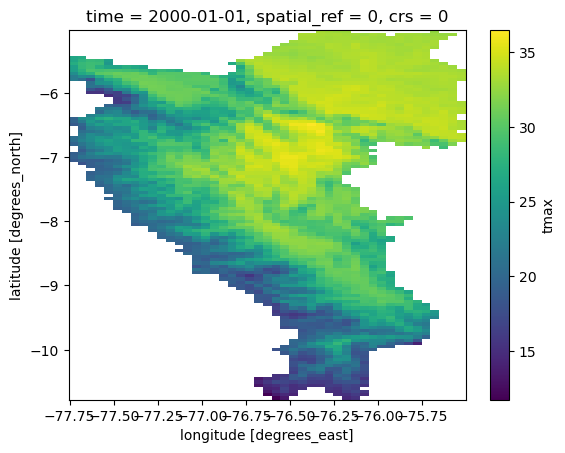

In [16]:
deschutes_ds.isel(time=0).plot()

In [17]:
deschutes_ds.rio.to_raster("D:/R/RFSI paper/BlockVC/raster_5km/tmax_daily.tif")

In [ ]:
# Definir nueva resolución (0.05 grados ~ 5 km)
nueva_resolucion = 0.05

# Calcular límites del raster recortado
bounds = deschutes_ds.rio.bounds()

In [ ]:
# Calcular nuevo ancho y alto basado en la nueva resolución
width = int((bounds[2] - bounds[0]) / nueva_resolucion)
height = int((bounds[3] - bounds[1]) / nueva_resolucion)

# Crear nueva transformada con la resolución deseada
nuevo_transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)

In [ ]:
# Reproyectar con interpolación bilineal
deschutes_resampled = deschutes_ds.rio.reproject(
    dst_crs=deschutes_ds.rio.crs,
    shape=(height, width),
    transform=nuevo_transform,
    resampling=Resampling.bilinear
)

In [ ]:
deschutes_resampled .isel(time=0).plot()

In [ ]:
# Guardar en formato GeoTIFF
#deschutes_resampled.rio.to_raster('D:/S/Serbia1km/Interpolation/Huallaga/tcwv_2000_2003.tif')